# Model 3: VGG16-Based Brain Tumor Classification

## 1: Verify Environment and Shared Dataset

This notebook implements Model 3 using the pretrained VGG16 architecture with TensorFlow.

The model will use the common dataset split prepared for all group models:

- Training: 4,343 images
- Validation: 1,086 images
- Testing: 1,584 images
- Classes: Glioma, Meningioma, No Tumor, Pituitary
- Split seed: 123
- Shared split file: `brain_tumor_split_seed123.csv`

The shared CSV will be used to ensure that all models are trained and evaluated using the same images and that exact duplicate images do not appear across different splits.

In [4]:

import sys
from pathlib import Path
import tensorflow as tf
import pandas as pd


print("Python:", sys.executable)
print("TensorFlow version:", tf.__version__)


print(
    "VGG16 available:",
    callable(tf.keras.applications.VGG16)
)


project_dir = Path.cwd()

if project_dir.name.lower() == "notebooks":
    project_dir = project_dir.parent


data_dir = project_dir / "data"
splits_dir = project_dir / "splits"

manifest_path = splits_dir / "brain_tumor_split_seed123.csv"


print("\nProject directory:")
print(project_dir)

print("\nData directory:")
print(data_dir)

print("\nShared split CSV:")
print(manifest_path)


print("\n--- PATH CHECK ---")

print("Data folder exists:", data_dir.is_dir())
print("Splits folder exists:", splits_dir.is_dir())
print("Shared CSV exists:", manifest_path.is_file())


training_dir = data_dir / "Training"
testing_dir = data_dir / "Testing"

print("\n--- ORIGINAL DATASET CHECK ---")

print("Training folder exists:", training_dir.is_dir())
print("Testing folder exists:", testing_dir.is_dir())


if manifest_path.is_file():
   
    print("The shared seed-123 CSV is available.")
else:
    
    print("The shared CSV was not found.")
    print("Expected location:")
    print(manifest_path)

Python: c:\Users\ASUS\anaconda3\envs\tensorflow\python.exe
TensorFlow version: 2.21.0
VGG16 available: True

Project directory:
c:\Users\ASUS\Desktop\DeepLearning_Project\SE4050-Deep-Learning-Assignment

Data directory:
c:\Users\ASUS\Desktop\DeepLearning_Project\SE4050-Deep-Learning-Assignment\data

Shared split CSV:
c:\Users\ASUS\Desktop\DeepLearning_Project\SE4050-Deep-Learning-Assignment\splits\brain_tumor_split_seed123.csv

--- PATH CHECK ---
Data folder exists: True
Splits folder exists: True
Shared CSV exists: True

--- ORIGINAL DATASET CHECK ---
Training folder exists: True
Testing folder exists: True
The shared seed-123 CSV is available.


#  2: Load and Verify the Shared Dataset Split

The shared CSV file `brain_tumor_split_seed123.csv` defines the exact
training, validation, and testing images for Model 3.

The CSV will be used instead of creating a new random split.

Expected dataset split:

- Training: 4,343 images
- Validation: 1,086 images
- Testing: 1,584 images
- Total: 7,013 unique images

Expected classes:

1. glioma
2. meningioma
3. notumor
4. pituitary

The SHA-256 hashes will also be checked to confirm that no exact duplicate
image appears more than once in the shared dataset split.

In [ ]:

split_df = pd.read_csv(manifest_path)

print("CSV loaded successfully.")
print("Number of rows:", len(split_df))


print("\n--- CSV COLUMNS ---")
print(split_df.columns.tolist())


required_columns = [
    "relative_path",
    "class_name",
    "class_id",
    "source_split",
    "split",
    "sha256"
]

missing_columns = [
    column for column in required_columns
    if column not in split_df.columns
]

print("\nMissing required columns:", missing_columns)


print("\n--- SPLIT COUNTS ---")
print(split_df["split"].value_counts())


print("\n--- CLASS COUNTS ---")
print(split_df["class_name"].value_counts())


print("\n--- CLASS DISTRIBUTION BY SPLIT ---")

class_split_table = pd.crosstab(
    split_df["class_name"],
    split_df["split"]
)

print(class_split_table)


expected_classes = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

actual_mapping = (
    split_df[["class_name", "class_id"]]
    .drop_duplicates()
    .sort_values("class_id")
)

print("\n--- CLASS MAPPING ---")
print(actual_mapping.to_string(index=False))


duplicate_hashes = split_df["sha256"].duplicated().sum()

print("\n--- DUPLICATE CHECK ---")
print("Duplicate SHA-256 entries:", duplicate_hashes)


duplicate_paths = split_df["relative_path"].duplicated().sum()

print("Duplicate file paths:", duplicate_paths)

expected_split_counts = {
    "train": 4343,
    "validation": 1086,
    "test": 1584
}

actual_split_counts = split_df["split"].value_counts().to_dict()

print("\n--- EXPECTED VS ACTUAL ---")

for split_name, expected_count in expected_split_counts.items():
    actual_count = actual_split_counts.get(split_name, 0)

    print(
        f"{split_name}: "
        f"expected = {expected_count}, "
        f"actual = {actual_count}"
    )


verification_passed = (
    len(split_df) == 7013
    and not missing_columns
    and actual_split_counts == expected_split_counts
    and set(split_df["class_name"].unique()) == set(expected_classes.keys())
    and duplicate_hashes == 0
    and duplicate_paths == 0
)

print("\n============================================================")

if verification_passed:
   
    print("The shared dataset split is correct.")
    print("Total unique images:", len(split_df))
else:
   
    print("Please check the output above.")

print("============================================================")

CSV loaded successfully.
Number of rows: 7013

--- CSV COLUMNS ---
['relative_path', 'class_name', 'class_id', 'source_split', 'split', 'sha256']

Missing required columns: []

--- SPLIT COUNTS ---
split
train         4343
test          1584
validation    1086
Name: count, dtype: int64

--- CLASS COUNTS ---
class_name
glioma        1786
meningioma    1784
pituitary     1762
notumor       1681
Name: count, dtype: int64

--- CLASS DISTRIBUTION BY SPLIT ---
split       test  train  validation
class_name                         
glioma       386   1120         280
meningioma   398   1109         277
notumor      400   1025         256
pituitary    400   1089         273

--- CLASS MAPPING ---
class_name  class_id
    glioma         0
meningioma         1
   notumor         2
 pituitary         3

--- DUPLICATE CHECK ---
Duplicate SHA-256 entries: 0
Duplicate file paths: 0

--- EXPECTED VS ACTUAL ---
train: expected = 4343, actual = 4343
validation: expected = 1086, actual = 1086
test: expe

#  3: Verify Image Files in the Shared Dataset

Before creating the TensorFlow datasets, verify that every image listed
in the shared CSV exists in the local dataset.

The CSV contains the relative path of each image. These paths will be
combined with the project `data` directory.

Expected result:

- 7,013 image files found
- 0 missing files

This ensures that the shared split can be loaded correctly for VGG16.

In [6]:


print("Checking image files...")
print("Total images in CSV:", len(split_df))


split_df["full_path"] = split_df["relative_path"].apply(
    lambda x: data_dir / x
)


split_df["file_exists"] = split_df["full_path"].apply(
    lambda x: x.is_file()
)

missing_files = split_df[~split_df["file_exists"]].copy()


print("\n--- FILE CHECK ---")
print("Total images:", len(split_df))
print("Existing images:", split_df["file_exists"].sum())
print("Missing images:", len(missing_files))


if len(missing_files) > 0:
    print("\n--- MISSING FILES ---")

    print(
        missing_files[
            ["relative_path", "class_name", "split"]
        ].to_string(index=False)
    )



if len(missing_files) == 0:
   
    print("All 7,013 image files exist.")
else:
   
    print(f"{len(missing_files)} image files are missing.")



Checking image files...
Total images in CSV: 7013

--- FILE CHECK ---
Total images: 7013
Existing images: 7013
Missing images: 0
All 7,013 image files exist.


#  4: Create TensorFlow Datasets

The training, validation, and testing datasets will be created directly
from the shared CSV file.

No new random split will be performed.

Dataset sizes:

- Training: 4,343 images
- Validation: 1,086 images
- Testing: 1,584 images

Images will be loaded as RGB images and prepared for the VGG16 model.

In [7]:


import numpy as np

train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "validation"].copy()
test_df = split_df[split_df["split"] == "test"].copy()


train_paths = train_df["full_path"].astype(str).values
train_labels = train_df["class_id"].astype(np.int32).values

val_paths = val_df["full_path"].astype(str).values
val_labels = val_df["class_id"].astype(np.int32).values

test_paths = test_df["full_path"].astype(str).values
test_labels = test_df["class_id"].astype(np.int32).values


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 4

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)



def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=123,
    reshuffle_each_iteration=True
)


train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)


train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)



print("\n--- DATASET INFORMATION ---")

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

print("\nTensorFlow datasets created successfully.")

Image size: (224, 224)
Batch size: 16
Number of classes: 4

--- DATASET INFORMATION ---
Training images: 4343
Validation images: 1086
Testing images: 1584

TensorFlow datasets created successfully.


# 5: Apply VGG16 Image Preprocessing

The pretrained VGG16 model expects images to be processed using
`tf.keras.applications.vgg16.preprocess_input`.

This preprocessing converts the resized RGB images into the format
expected by the VGG16 ImageNet weights.

The same preprocessing is applied to the training, validation, and
testing datasets.

In [10]:

vgg16_preprocess = tf.keras.applications.vgg16.preprocess_input




train_ds = train_ds.map(
    lambda image, label: (
        vgg16_preprocess(image),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda image, label: (
        vgg16_preprocess(image),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda image, label: (
        vgg16_preprocess(image),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)




train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)




sample_images, sample_labels = next(iter(train_ds))





print("Sample image batch shape:", sample_images.shape)
print("Sample label batch shape:", sample_labels.shape)

print("Minimum pixel value:", tf.reduce_min(sample_images).numpy())
print("Maximum pixel value:", tf.reduce_max(sample_images).numpy())

print("\nVGG16 preprocessing applied successfully.")


Sample image batch shape: (16, 224, 224, 3)
Sample label batch shape: (16,)
Minimum pixel value: -351.299
Maximum pixel value: -76.558

VGG16 preprocessing applied successfully.


#  6: Build the VGG16 Model

VGG16 is used as a pretrained feature extractor with ImageNet weights.

The original VGG16 classification layer is removed using `include_top=False`.

The Model 3 classification head consists of:

- VGG16 pretrained convolutional base
- Global Average Pooling
- Dense layer with 256 neurons and ReLU activation
- Dropout with a rate of 0.5
- Dense output layer with 4 neurons and Softmax activation

The VGG16 base is frozen initially so that the newly added classification
layers can learn the four brain tumor classes.

Classes:

- Glioma
- Meningioma
- No Tumor
- Pituitary

In [12]:


from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models



base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)



base_model.trainable = False



model3 = models.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(
        256,
        activation="relu"
    ),
    
    layers.Dropout(0.5),
    
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])




print("MODEL 3 - VGG16")


model3.summary()

MODEL 3 - VGG16


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# 7: Compile the VGG16 Model

The VGG16 model will be compiled for four-class brain tumor
classification.

Configuration:

- Optimizer: Adam
- Learning rate: 0.001
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy

The labels in the TensorFlow datasets are integer class IDs
(0, 1, 2, 3), so `SparseCategoricalCrossentropy` is used instead of
`CategoricalCrossentropy`.

In [15]:


from tensorflow.keras.optimizers import Adam



LEARNING_RATE = 0.001




model3.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=[
        "accuracy"
    ]
)





print(" VGG16 MODEL COMPILED")


print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)
print("Loss: Sparse Categorical Crossentropy")
print("Metric: Accuracy")

print("\nTrainable parameters:",
      model3.count_params() - base_model.count_params())

print("Total parameters:",
      model3.count_params())

print("\nModel compilation successful.")


 VGG16 MODEL COMPILED
Optimizer: Adam
Learning rate: 0.001
Loss: Sparse Categorical Crossentropy
Metric: Accuracy

Trainable parameters: 132356
Total parameters: 14847044

Model compilation successful.


#  8: Train the VGG16 Model

The VGG16 model will be trained using the official shared training
and validation datasets.

Training configuration:

- Epochs: 10
- Batch size: 16
- Training images: 4,343
- Validation images: 1,086
- Optimizer: Adam
- Learning rate: 0.001
- Loss: Sparse Categorical Crossentropy

ModelCheckpoint is used to save the model with the best validation
accuracy during training.

The test dataset is NOT used during training.

In [16]:


from tensorflow.keras.callbacks import ModelCheckpoint



EPOCHS = 10

MODEL_PATH = "model3_vgg16_best.keras"




checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)





print(" STARTING VGG16 TRAINING")


history = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    verbose=1
)


print("VGG16 TRAINING COMPLETED")


print("Best model saved as:")
print(MODEL_PATH)

 STARTING VGG16 TRAINING
Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6336 - loss: 2.5708
Epoch 1: val_accuracy improved from None to 0.86096, saving model to model3_vgg16_best.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 2796s 10s/step - accuracy: 0.7267 - loss: 1.3049 - val_accuracy: 0.8610 - val_loss: 0.3863
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 41s/step - accuracy: 0.8216 - loss: 0.4481 
Epoch 2: val_accuracy improved from 0.86096 to 0.88029, saving model to model3_vgg16_best.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 11614s 43s/step - accuracy: 0.8229 - loss: 0.4501 - val_accuracy: 0.8803 - val_loss: 0.3404
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8562 - loss: 0.3575
Epoch 3: val_accuracy did not improve from 0.88029
272/272 ━━━━━━━━━━━━━━━━━━━━ 1935s 7s/step - accuracy: 0.8621 - loss: 0.3630 - val_accuracy: 0.8766 - val_loss: 0.3098
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8848 - loss: 0.3004
Epoch 4: val_accuracy improved fr

## 9 — Training and Validation Performance

The training history is visualized using accuracy and loss curves.
These plots help identify the learning behavior of the VGG16 model
and check for possible overfitting.

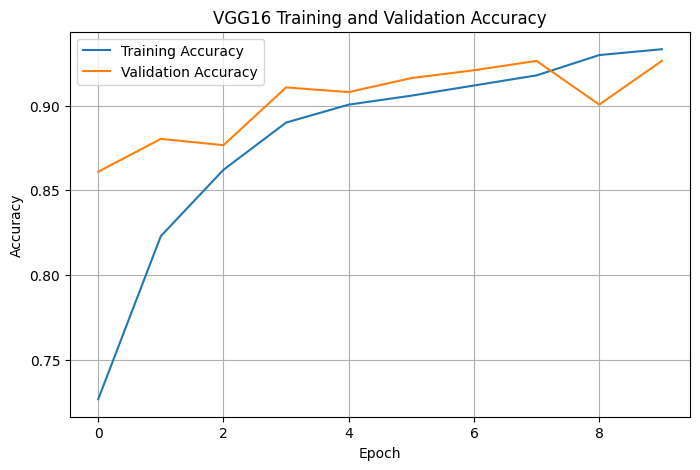

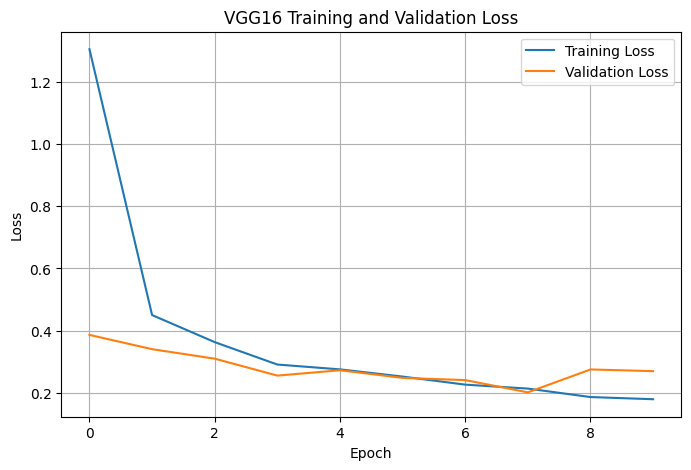

In [18]:
import matplotlib.pyplot as plt


history_dict = history.history


plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["loss"],
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



best_epoch = history_dict["val_accuracy"].index(
    max(history_dict["val_accuracy"])
) + 1

best_val_accuracy = max(history_dict["val_accuracy"])



##  10 — Load the Best VGG16 Model

The best VGG16 model saved during training is loaded from the
ModelCheckpoint file. The saved model is selected based on the
highest validation accuracy.

In [20]:
from tensorflow.keras.models import load_model

BEST_MODEL_PATH = "model3_vgg16_best.keras"

best_model3 = load_model(BEST_MODEL_PATH)


print("BEST VGG16 MODEL LOADED")


print("Model file:", BEST_MODEL_PATH)
print("Total parameters:", best_model3.count_params())

print("\nModel input shape:", best_model3.input_shape)
print("Model output shape:", best_model3.output_shape)

print("\nBest validation accuracy from training:")
print(f"{max(history.history['val_accuracy']) * 100:.2f}%")

BEST VGG16 MODEL LOADED
Model file: model3_vgg16_best.keras
Total parameters: 14847044

Model input shape: (None, 224, 224, 3)
Model output shape: (None, 4)

Best validation accuracy from training:
92.63%


## 11 — Final Test Set Evaluation

The best VGG16 model is evaluated on the independent test set.
The test set contains 1,584 images that were not used during
training or validation.

In [21]:
print("=" * 60)
print("STEP 11: FINAL TEST SET EVALUATION")
print("=" * 60)

test_loss, test_accuracy = best_model3.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

STEP 11: FINAL TEST SET EVALUATION
99/99 ━━━━━━━━━━━━━━━━━━━━ 603s 6s/step - accuracy: 0.9003 - loss: 0.4710

FINAL TEST RESULTS
Test Loss: 0.4710
Test Accuracy: 0.9003
Test Accuracy: 90.03%


## 12 — Classification Report and Confusion Matrix

The best VGG16 model is used to generate predictions for the
independent test set. Precision, recall, F1-score, and a
confusion matrix are calculated for each brain tumor class.

In [23]:
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

print("Class names:", CLASS_NAMES)

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


GENERATING TEST SET PREDICTIONS
99/99 ━━━━━━━━━━━━━━━━━━━━ 459s 5s/step

Prediction completed.
Number of actual labels: 1584
Number of predictions: 1584

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.9392    0.7202    0.8152       386
  meningioma     0.7863    0.9246    0.8499       398
     notumor     0.9406    0.9900    0.9647       400
   pituitary     0.9624    0.9600    0.9612       400

    accuracy                         0.9003      1584
   macro avg     0.9071    0.8987    0.8978      1584
weighted avg     0.9070    0.9003    0.8985      1584

CONFUSION MATRIX
[[278  82  19   7]
 [ 17 368   5   8]
 [  0   4 396   0]
 [  1  14   1 384]]


<Figure size 800x600 with 0 Axes>

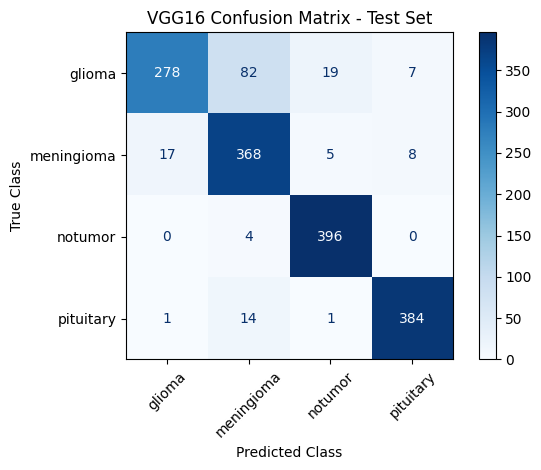

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


print("=" * 60)
print("GENERATING TEST SET PREDICTIONS")
print("=" * 60)

y_true = test_labels

y_prob = best_model3.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

print("\nPrediction completed.")

print("Number of actual labels:", len(y_true))
print("Number of predictions:", len(y_pred))


print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)


cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

# -----------------------------------------
# Display Confusion Matrix
# -----------------------------------------
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    values_format="d",
    cmap="Blues"
)

plt.title("VGG16 Confusion Matrix - Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13 — Multi-Class ROC-AUC Evaluation

The multi-class ROC-AUC score is calculated using a one-vs-rest
(OVR) strategy for the four brain tumor classes.

In [26]:
from sklearn.metrics import roc_auc_score

print("=" * 60)
print(" ROC-AUC EVALUATION")
print("=" * 60)

# Multi-class ROC-AUC using One-vs-Rest strategy
roc_auc_macro = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="macro"
)

roc_auc_weighted = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(f"Macro ROC-AUC:    {roc_auc_macro:.4f}")
print(f"Macro ROC-AUC:    {roc_auc_macro * 100:.2f}%")

print(f"\nWeighted ROC-AUC: {roc_auc_weighted:.4f}")
print(f"Weighted ROC-AUC: {roc_auc_weighted * 100:.2f}%")

 ROC-AUC EVALUATION
Macro ROC-AUC:    0.9737
Macro ROC-AUC:    97.37%

Weighted ROC-AUC: 0.9741
Weighted ROC-AUC: 97.41%


## 14 — Save Model 3 Results

The trained VGG16 model, training history, classification report,
confusion matrix, and final evaluation metrics are saved for
documentation and comparison with the other models.

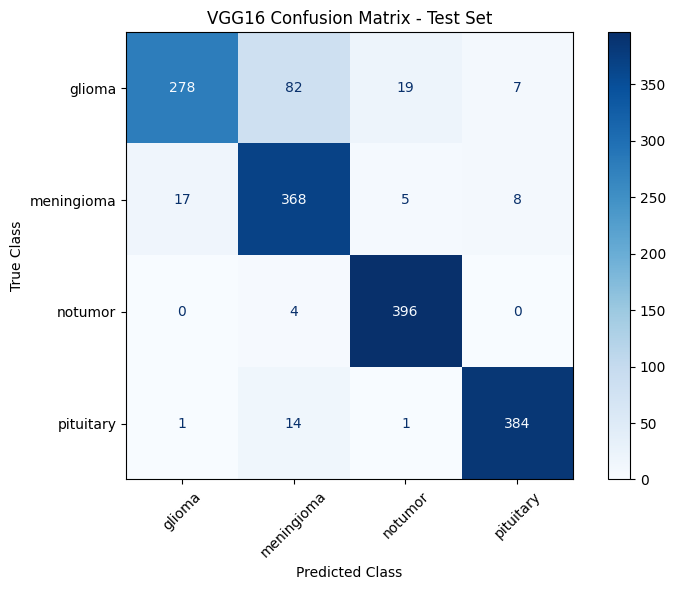

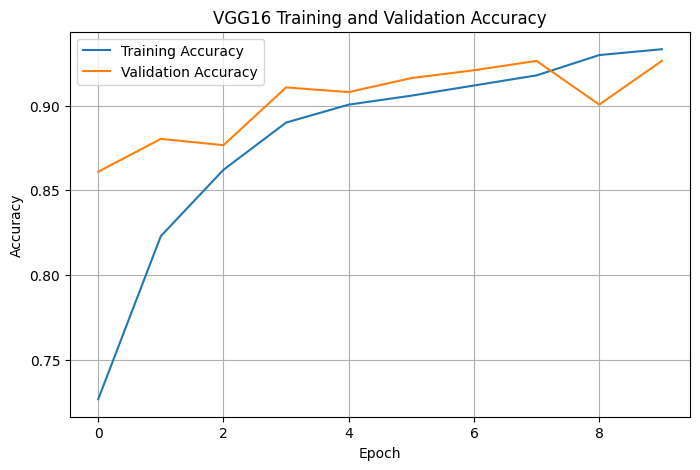

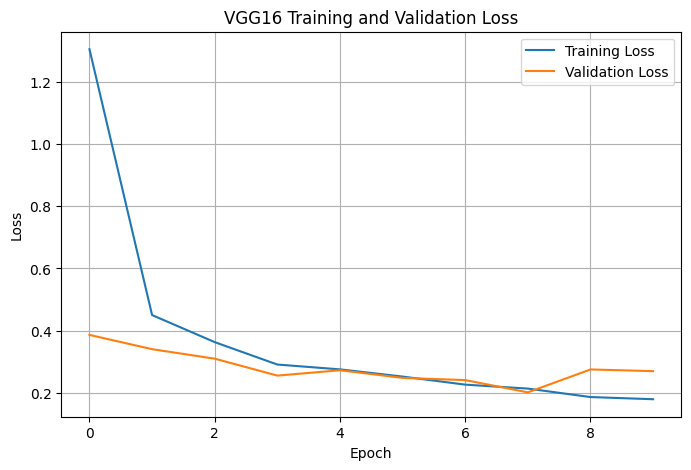

MODEL 3 RESULTS SAVED
vgg16_accuracy.png
vgg16_classification_report.csv
vgg16_confusion_matrix.csv
vgg16_confusion_matrix.png
vgg16_final_metrics.json
vgg16_loss.png
vgg16_training_history.csv

Final Metrics:
Best Validation Accuracy : 92.63%
Test Accuracy            : 90.03%
Test Loss                : 0.4710
Macro F1-score           : 89.78%
Weighted F1-score        : 89.85%
Macro ROC-AUC            : 97.37%
Weighted ROC-AUC         : 97.41%


In [27]:
import os
import json
import pandas as pd
import numpy as np

results_dir = "model3_results"
os.makedirs(results_dir, exist_ok=True)


history_df = pd.DataFrame(history.history)

history_path = os.path.join(
    results_dir,
    "vgg16_training_history.csv"
)

history_df.to_csv(history_path, index=False)


report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = os.path.join(
    results_dir,
    "vgg16_classification_report.csv"
)

report_df.to_csv(report_path)


cm_path = os.path.join(
    results_dir,
    "vgg16_confusion_matrix.csv"
)

pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(cm_path)


metrics = {
    "best_validation_accuracy": float(
        max(history.history["val_accuracy"])
    ),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
    "macro_roc_auc": float(roc_auc_macro),
    "weighted_roc_auc": float(roc_auc_weighted)
}

metrics_path = os.path.join(
    results_dir,
    "vgg16_final_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    values_format="d",
    cmap="Blues",
    ax=ax
)

ax.set_title("VGG16 Confusion Matrix - Test Set")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

plt.xticks(rotation=45)
plt.tight_layout()

cm_figure_path = os.path.join(
    results_dir,
    "vgg16_confusion_matrix.png"
)

plt.savefig(cm_figure_path, dpi=300, bbox_inches="tight")
plt.show()



# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_figure_path = os.path.join(
    results_dir,
    "vgg16_accuracy.png"
)

plt.savefig(
    accuracy_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_figure_path = os.path.join(
    results_dir,
    "vgg16_loss.png"
)

plt.savefig(
    loss_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()



print("=" * 60)
print("MODEL 3 RESULTS SAVED")
print("=" * 60)

for file_name in os.listdir(results_dir):
    print(file_name)

print("\nFinal Metrics:")
print(f"Best Validation Accuracy : {metrics['best_validation_accuracy'] * 100:.2f}%")
print(f"Test Accuracy            : {metrics['test_accuracy'] * 100:.2f}%")
print(f"Test Loss                : {metrics['test_loss']:.4f}")
print(f"Macro F1-score           : {metrics['macro_f1'] * 100:.2f}%")
print(f"Weighted F1-score        : {metrics['weighted_f1'] * 100:.2f}%")
print(f"Macro ROC-AUC            : {metrics['macro_roc_auc'] * 100:.2f}%")
print(f"Weighted ROC-AUC         : {metrics['weighted_roc_auc'] * 100:.2f}%")